# ДЗ 2

In [5]:
import math
import numpy as np
import matplotlib.pyplot as plt
from numpy.testing import assert_allclose
from scipy.integrate import simpson

np.random.seed(42)

## 1. Двухточечная квадратура Гаусса

На промежутке $[-1, 1]\$ узлы: $x_{1,2} = \pm \frac{1}{\sqrt{3}}$, веса $\omega_{1,2} = 1$.

Переходя на $[a, b]$ узлы меняются по закону:
$$
\xi = \frac{a+b}{2} + \frac{b-a}{2}x, \qquad \mathrm{d}\xi = \frac{b-a}{2}\mathrm{d}x
$$

А веса масштабируются множителем $\frac{b-a}{2}$, т.к.


$$
\int_a^b f(x)\,\mathrm{d}x = \frac{b-a}{2} \int_{-1}^1 f(\xi(x))\,\mathrm{d}x
$$

In [6]:
def gauss_2(a, b):
    r"""Return nodes and weights for a two-point Gauss quadrature on [a, b].

    Parameters
    ----------
    a, b : float
        Boundaries of the integration interval

    Returns
    -------
    x1, x2, w1, w2 : float
        Nodes and weights of the quadrature.
    """
    mid = (a + b) / 2.0
    half = (b - a) / 2.0
    x1 = mid - half / np.sqrt(3)
    x2 = mid + half / np.sqrt(3)
    w1 = half
    w2 = half
    return x1, x2, w1, w2

x1, x2, w1, w2 = gauss_2(0, 1)

def f(x, n):
    return x**n

for n in [0, 1, 2, 3]:
    assert_allclose(w1 * f(x1, n=n) + w2 * f(x2, n=n),
                    1. / (n + 1), atol=1e-14)

## 2. Вычитание интегрируемых сингулярностей

Рассмотрим интеграл:
$$I = \int_0^1 \frac{e^x}{\sqrt{x(1-x)}}\,dx$$

Подынтегральная функция имеет сингулярности при $x=0$ и $x=1$.

Представим его как:

$$
I = \int_0^1 \frac{e^x - 1 - (e-1)x}{\sqrt{x(1-x)}}\,dx + \int_0^1 \frac{1 + (e-1)x}{\sqrt{x(1-x)}}\,dx
$$

Второе слагаемое вычислимо аналитически:
$$\int_0^1 \frac{1 + (e-1)x}{\sqrt{x(1-x)}}\,dx = \pi + (e-1)\frac{\pi}{2} = \frac{\pi(e+1)}{2}$$

Покажем, что к первому интегралу можно применить методом трапеции (т.е. то что обе сингулярности сняты):
- При $x \to 0 \ \text{числитель} \ e^x - 1 - (e-1)x = x - (e-1)x + o(x^2)$
- При $x \to 1 \ \text{числитель} \ e^x - 1 - (e-1)x \big|_{x=1} = \left/ t = x-1 \right/ = e(1 + o(t)) - 1 - (e-1)(t+1) = e - 1 - e + 1 + o(t) = o(x)$

Т.к. в знаменателе $\sqrt{x}$ (или $\sqrt{t}$) интеграл дейтсвительно сходится

In [7]:
def integ(npts=10):
    """Compute the value of the integral above.

    Subtract the singularities and use the trapezoid rule.

    Parameters
    ----------
    npts : int
        The number of points for the trapezoid rule

    Returns
    -------
    I : float
        The computed value of the integral
    """
    x = np.linspace(0, 1, npts + 1)

    P = lambda t: 1.0 + (np.e - 1.0) * t

    g = np.zeros_like(x)
    mask = (x > 0) & (x < 1)
    g[mask] = (np.exp(x[mask]) - P(x[mask])) / np.sqrt(x[mask] * (1.0 - x[mask]))
    g[0] = 0.0
    g[-1] = 0.0

    I_trap = np.trapz(g, x)
    I_analytic = np.pi * (np.e + 1.0) / 2.0

    return I_trap + I_analytic

I_fine = integ(npts=10000)
I_half = integ(npts=5000)

print(f"I(n=100)   = {integ(100):.10f}")
print(f"I(n=1000)  = {integ(1000):.10f}")
print(f"I(n=5000)  = {I_half:.10f}")
print(f"I(n=10000) = {I_fine:.10f}")

runge_error = abs(I_fine - I_half) / 3.0
print(f"\nОценка погрешности по Рунге: {runge_error:.2e}")

I(n=100)   = 5.5087867262
I(n=1000)  = 5.5084410690
I(n=5000)  = 5.5084307842
I(n=10000) = 5.5084301311

Оценка погрешности по Рунге: 2.18e-07


/tmp/ipykernel_971605/2399880071.py:26: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  I_trap = np.trapz(g, x)


## 4. Вычисление интеграла с внутренней особенностью

Рассмотрим интеграл:
$$J = \int_{-0.5}^{0.5} |x|^{-1/2}\,(1-x)^{-1/2}\,dx$$

Тогда разбиение интеграла с особенностью около 0 имеет вид:
$$J = \int_{-0.5}^{-\delta_1} |x|^{-1/2}(1-x)^{-1/2}\,dx + \int_{-\delta_1}^{\delta_2} |x|^{-1/2}(1-x)^{-1/2}\,dx + \int_{\delta_2}^{0.5} |x|^{-1/2}(1-x)^{-1/2}\,dx$$

#### Правая часть, $x \in (0, \delta_2)$

Рассмотрим
$$I_+(\delta_2) = \int_0^{\delta_2} x^{-1/2}(1-x)^{-1/2}\,dx.$$
Сделаем замену $x = \sin^2\theta$. Тогда $dx = 2\sin\theta\cos\theta\,d\theta$, $\sqrt{x}=\sin\theta$, $\sqrt{1-x}=\cos\theta$:
$$I_+(\delta_2) = \int_0^{\arcsin\sqrt{\delta_2}} \frac{2\sin\theta\cos\theta}{\sin\theta\cos\theta}\,d\theta = 2\arcsin\sqrt{\delta_2}.$$

#### Левая часть, $x \in (-\delta_1, 0)$

Рассмотрим
$$I_-(\delta_1) = \int_{-\delta_1}^{0} |x|^{-1/2}(1-x)^{-1/2}\,dx.$$
Положим $t=-x$:
$$I_-(\delta_1) = \int_{0}^{\delta_1} t^{-1/2}(1+t)^{-1/2}\,dt.$$
Сделаем замену $t = \sinh^2 u$, тогда $dt = 2\sinh u\cosh u\,du$, $\sqrt{t}=\sinh u$, $\sqrt{1+t}=\cosh u$:
$$I_-(\delta_1) = \int_0^{\operatorname{arsinh}\sqrt{\delta_1}} \frac{2\sinh u\cosh u}{\sinh u\cosh u}\,du = 2\operatorname{arsinh}\sqrt{\delta_1}.$$

Итого вклад вырезанной окрестности:
$$\int_{-\delta_1}^{\delta_2} |x|^{-1/2}(1-x)^{-1/2}\,dx = 2\operatorname{arsinh}\sqrt{\delta_1} + 2\arcsin\sqrt{\delta_2}.$$

Для малых $u$:
$$\arcsin u = u + \frac{u^3}{6} + O(u^5), \qquad \operatorname{arsinh} u = u - \frac{u^3}{6} + O(u^5).$$
Тогда достаточно взять
$$\delta_2 = \left| \delta_1 \right| = \frac{\varepsilon^2}{16}$$

## 5. Интеграл от быстроосциллирующей функции

In [8]:
def exact_integral(k):
    return (k - np.exp(-np.pi) * (k * np.cos(k * np.pi) + np.sin(k * np.pi))) / (1 + k**2)

def int_xm_sin_kx(m, k, a=0, b=np.pi):
    if m == 0:
        return (-np.cos(k * b) + np.cos(k * a)) / k
    return (-b**m * np.cos(k * b) + a**m * np.cos(k * a)) / k + m / k * int_xm_cos_kx(m - 1, k, a, b)

def int_xm_cos_kx(m, k, a=0, b=np.pi):
    if m == 0:
        return (np.sin(k * b) - np.sin(k * a)) / k
    return (b**m * np.sin(k * b) - a**m * np.sin(k * a)) / k - m / k * int_xm_sin_kx(m - 1, k, a, b)

def poly_approx_integral(k, degree):
    coeffs = [(-1)**m / math.factorial(m) for m in range(degree + 1)]
    result = 0.0
    for m, c in enumerate(coeffs):
        result += c * int_xm_sin_kx(m, k)
    return result

def simpson_integral(k, npts):
    x = np.linspace(0, np.pi, npts)
    y = np.exp(-x) * np.sin(k * x)
    return simpson(y, x=x)

def subtraction_integral(k, degree, npts):
    coeffs = [(-1)**m / math.factorial(m) for m in range(degree + 1)]
    poly = lambda x: sum(c * x**m for m, c in enumerate(coeffs))

    x = np.linspace(0, np.pi, npts)
    remainder = (np.exp(-x) - np.array([poly(xi) for xi in x])) * np.sin(k * x)
    I_remainder = simpson(remainder, x=x)
    I_poly = poly_approx_integral(k, degree)
    return I_remainder + I_poly

k_values = [5, 10, 20, 50, 100]
npts_values = [101, 201, 501, 1001]

print(f"{'k':>5} {'npts':>6} {'Simpson err':>14} {'Substr deg2 err':>16} {'Substr deg3 err':>16}")
print("-" * 60)

for k in k_values:
    I_exact = exact_integral(k)
    for npts in npts_values:
        I_simp = simpson_integral(k, npts)
        I_sub2 = subtraction_integral(k, 2, npts)
        I_sub3 = subtraction_integral(k, 3, npts)
        print(f"{k:>5} {npts:>6} {abs(I_simp - I_exact):>14.2e} {abs(I_sub2 - I_exact):>16.2e} {abs(I_sub3 - I_exact):>16.2e}")

    k   npts    Simpson err  Substr deg2 err  Substr deg3 err
------------------------------------------------------------
    5    101       6.22e-07         1.79e-06         1.46e-06
    5    201       3.88e-08         1.11e-07         9.12e-08
    5    501       9.94e-10         2.85e-09         2.33e-09
    5   1001       6.21e-11         1.78e-10         1.46e-10
   10    101       5.08e-06         1.49e-05         1.29e-05
   10    201       3.15e-07         9.23e-07         7.98e-07
   10    501       8.04e-09         2.36e-08         2.04e-08
   10   1001       5.02e-10         1.47e-09         1.27e-09
   20    101       4.31e-05         1.25e-04         1.09e-04
   20    201       2.60e-06         7.51e-06         6.57e-06
   20    501       6.59e-08         1.90e-07         1.67e-07
   20   1001       4.11e-09         1.19e-08         1.04e-08
   50    101       9.01e-04         2.59e-03         2.28e-03
   50    201       4.36e-05         1.25e-04         1.10e-04
   50    

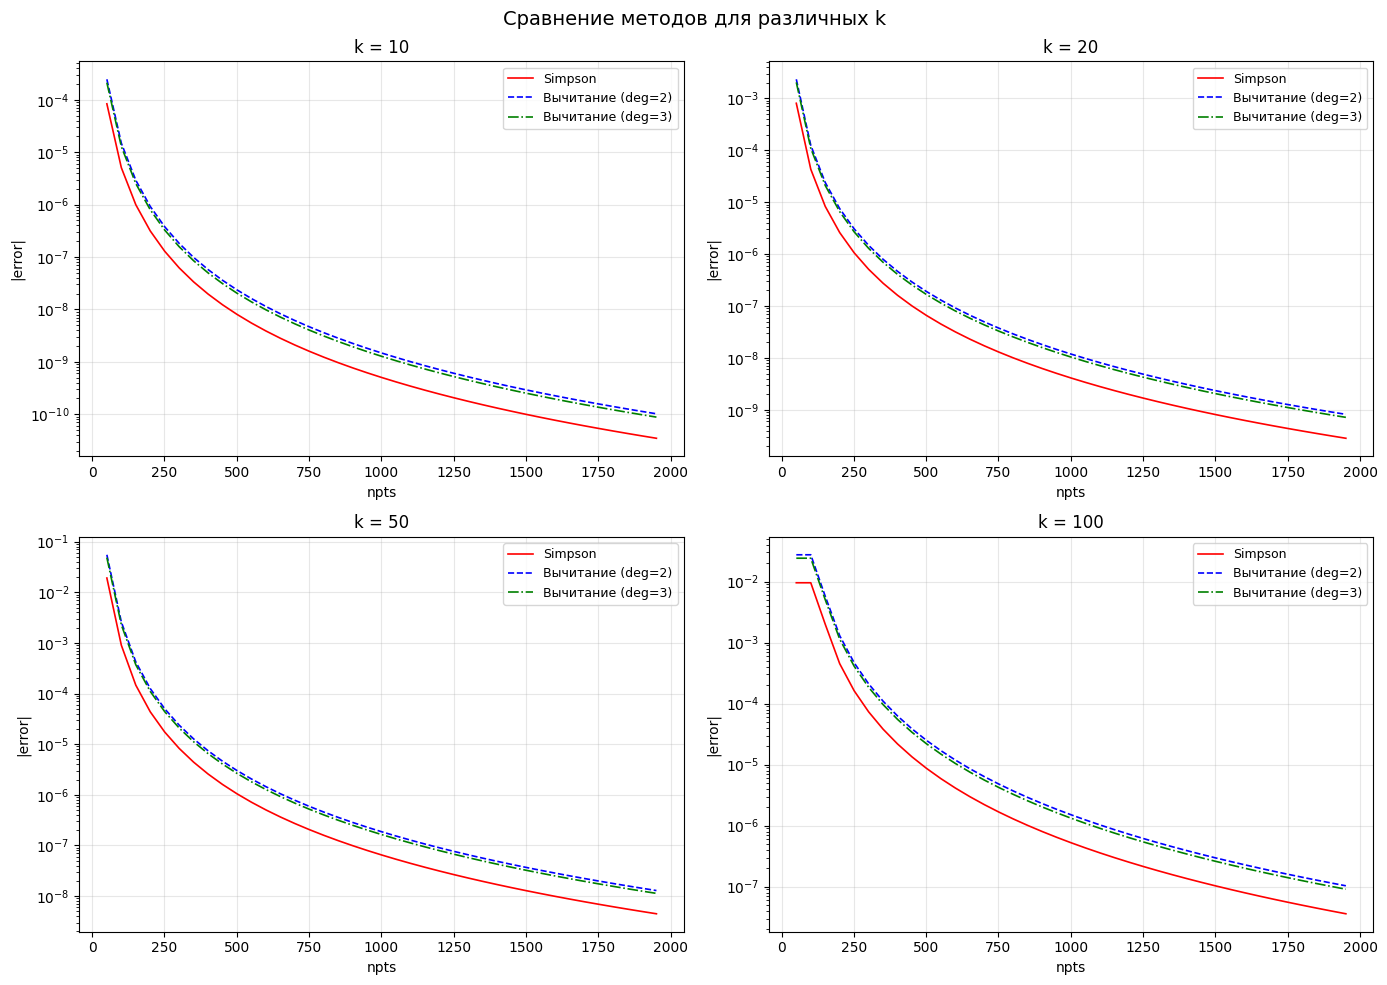

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Сравнение методов для различных k', fontsize=14)

for idx, k in enumerate([10, 20, 50, 100]):
    ax = axes[idx // 2, idx % 2]
    I_exact = exact_integral(k)

    npts_range = np.arange(51, 2001, 50)
    err_simp = []
    err_sub2 = []
    err_sub3 = []

    for npts in npts_range:
        err_simp.append(abs(simpson_integral(k, npts) - I_exact))
        err_sub2.append(abs(subtraction_integral(k, 2, npts) - I_exact))
        err_sub3.append(abs(subtraction_integral(k, 3, npts) - I_exact))

    ax.semilogy(npts_range, err_simp, 'r-', linewidth=1.2, label='Simpson')
    ax.semilogy(npts_range, err_sub2, 'b--', linewidth=1.2, label='Вычитание (deg=2)')
    ax.semilogy(npts_range, err_sub3, 'g-.', linewidth=1.2, label='Вычитание (deg=3)')
    ax.set_title(f'k = {k}')
    ax.set_xlabel('npts')
    ax.set_ylabel('|error|')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()